In [86]:
#Importing required libraries.
import pandas as pd
import zipfile
import os

# Load and inspect the stations dataset
stations_df = pd.read_csv('stations.csv') # or 'data/stations.csv' if extracted
print("Stations shape:", stations_df.shape)
display(stations_df.head(3))

Stations shape: (152, 22)


,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN


Stations per City:
 city
Bengaluru    34
Delhi NCR    30
Hyderabad    26
Pune         22
Mumbai       22
Jaipur       18
Name: count, dtype: int64


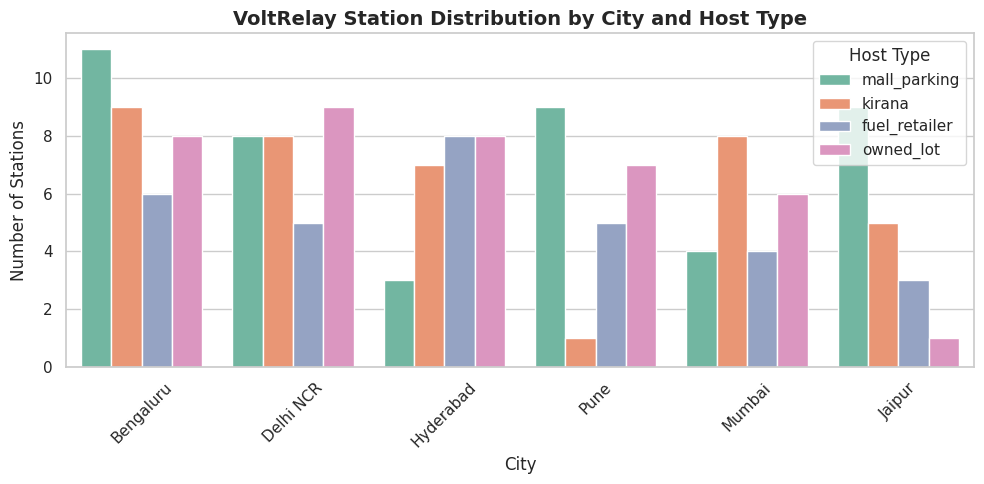

In [87]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style like a pro
sns.set_theme(style="whitegrid")

# 1. Check station distribution by City
city_counts = stations_df['city'].value_counts()
print("Stations per City:\n", city_counts)

# 2. Quick breakdown by Host Type and Location Type
plt.figure(figsize=(10, 5))
sns.countplot(data=stations_df, x='city', hue='host_type', palette='Set2')
plt.title("VoltRelay Station Distribution by City and Host Type", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Stations", fontsize=12)
plt.legend(title="Host Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
import pandas as pd

# Load the riders dataset
riders_df = pd.read_csv('riders.csv')

# Check shape and columns
print("Riders Shape:", riders_df.shape)
display(riders_df.head(3))

Riders Shape: (20000, 12)


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad


In [89]:
import pandas as pd

# Load the batteries dataset
batteries_df = pd.read_csv('batteries.csv')

# Check shape and columns
print("Batteries Shape:", batteries_df.shape)
display(batteries_df.head(3))

Batteries Shape: (6500, 13)


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0


Batteries loaded successfully, shape: (6500, 13)

Supplier breakdown (check this before writing recommendations):


,supplier,total_batteries,avg_degradation,avg_purchase_cost
0,Amptek,1307,18.189212,37724.116297
1,Cellora,3555,18.254740,37245.407876
2,Kyron,1638,35.457692,37532.742979


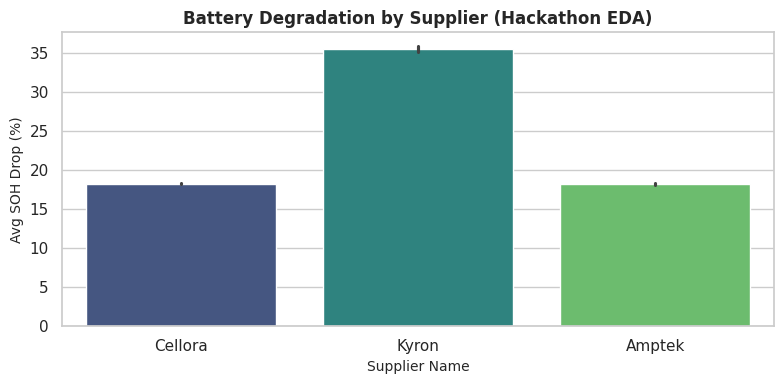

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# let's load batteries and check wear & tear across suppliers
batteries_df = pd.read_csv('batteries.csv')
print("Batteries loaded successfully, shape:", batteries_df.shape)

# quick check: drop any weird rows if needed, then calculate total SOH drop
batteries_df['soh_degradation'] = batteries_df['initial_soh_pct'] - batteries_df['current_soh_pct']

# group by supplier to see which vendor's batteries are dying faster
supplier_analysis = batteries_df.groupby('supplier').agg(
    total_batteries=('battery_id', 'count'),
    avg_degradation=('soh_degradation', 'mean'),
    avg_purchase_cost=('purchase_cost_inr', 'mean')
).reset_index()

print("\nSupplier breakdown (check this before writing recommendations):")
display(supplier_analysis)

# plotting this so we can throw it into the final presentation deck
plt.figure(figsize=(8, 4))
sns.barplot(
    data=batteries_df,
    x='supplier',
    y='soh_degradation',
    hue='supplier',       # Yeh warning hatane ke liye add kiya hai
    palette='viridis',
    legend=False          # Yeh legend hide karne ke liye add kiya hai
)
plt.title("Battery Degradation by Supplier (Hackathon EDA)", fontsize=12, fontweight='bold')
plt.xlabel("Supplier Name", fontsize=10)
plt.ylabel("Avg SOH Drop (%)", fontsize=10)
plt.tight_layout()
plt.show()

Loading swap_events.csv... give it a quick second ☕
Swap Events Shape: (3877013, 22)

Columns available: ['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Swap Event Types Breakdown (%):
event_type
swap_completed               94.036543
failed_no_charged_battery     3.466303
abandoned_queue               1.767675
cancelled_by_rider            0.431053
failed_system_error           0.298426
Name: proportion, dtype: float64


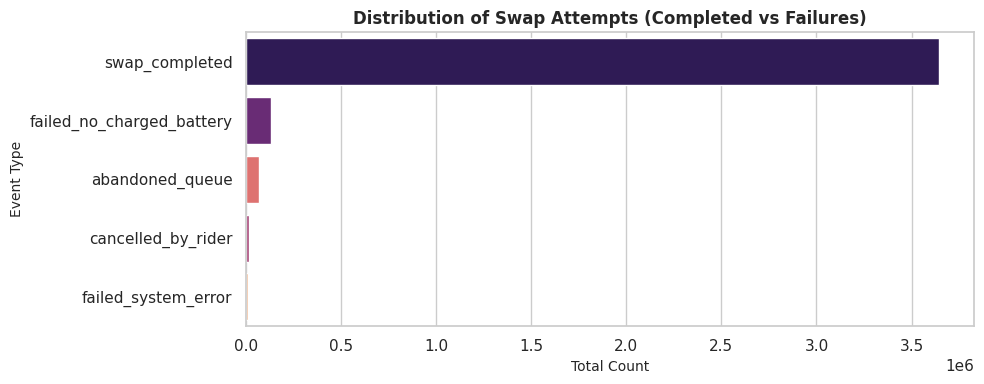

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# fixed filename to match what's actually uploaded in our Colab folder
print("Loading swap_events.csv... give it a quick second ☕")
swap_df = pd.read_csv('swap_events.csv')

# check shape - should be around 3.8M rows and 22 columns
print("Swap Events Shape:", swap_df.shape)

# quick look at columns to make sure data types are clean
print("\nColumns available:", swap_df.columns.tolist())

# check event types to analyze service failures (Core Question 1 & 2)
event_counts = swap_df['event_type'].value_counts(normalize=True) * 100
print("\nSwap Event Types Breakdown (%):")
print(event_counts)

# plot this out for the presentation slides
plt.figure(figsize=(10, 4))
sns.countplot(
    data=swap_df,
    y='event_type',
    order=swap_df['event_type'].value_counts().index,
    hue='event_type',    # Warning hatane ke liye add kiya hai
    palette='magma',
    legend=False         # Legend hide karne ke liye add kiya hai
)
plt.title("Distribution of Swap Attempts (Completed vs Failures)", fontsize=12, fontweight='bold')
plt.xlabel("Total Count", fontsize=10)
plt.ylabel("Event Type", fontsize=10)
plt.tight_layout()
plt.show()

In [92]:
# ==========================================
# STEP 3: STATION HOURLY TELEMETRY
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load hourly telemetry data (this one's a bit chunky, let's see how it looks)
print("loading hourly status csv...")
hourly_df = pd.read_csv('station_hourly_status.csv')

print("hourly status shape:", hourly_df.shape)
print("columns:", hourly_df.columns.tolist())

# quick check: which stations are constantly losing power?
# summing up outage minutes per station to find the worst spots
outage_check = hourly_df.groupby('station_id')['outage_minutes'].sum().reset_index()
worst_stations = outage_check.sort_values(by='outage_minutes', ascending=False).head(5)

print("\n--- top 5 stations with highest downtime (check if these match customer complaints later) ---")
display(worst_stations)

# quick stat check on temps and online chargers
print("\n--- quick stats on telemetry ---")
display(hourly_df[['ambient_temp_c', 'cabinet_temp_c', 'outage_minutes', 'chargers_online']].describe())

loading hourly status csv...
hourly status shape: (1487712, 14)
columns: ['station_id', 'hour_start', 'charged_2w_avg', 'charged_2w_min', 'charged_3w_min', 'packs_charging', 'packs_quarantined', 'chargers_online', 'ambient_temp_c', 'cabinet_temp_c', 'avg_charge_minutes', 'outage_minutes', 'grid_kwh', 'telemetry_status']

--- top 5 stations with highest downtime (check if these match customer complaints later) ---


,station_id,outage_minutes
113,STN-MUM-118,1140
117,STN-MUM-122,720
107,STN-MUM-112,600
106,STN-MUM-111,540
112,STN-MUM-117,540



--- quick stats on telemetry ---


,ambient_temp_c,cabinet_temp_c,outage_minutes,chargers_online
count,1.478328e+06,1.478328e+06,1.487712e+06,1.487712e+06
mean,1.845586e+01,2.502770e+01,1.242176e-02,1.475399e+01
std,8.687845e+00,9.229253e+00,8.632217e-01,4.164915e+00
min,1.000000e+00,4.100000e+00,0.000000e+00,6.000000e+00
25%,1.180000e+01,1.790000e+01,0.000000e+00,1.200000e+01
50%,1.720000e+01,2.360000e+01,0.000000e+00,1.600000e+01
75%,2.300000e+01,3.020000e+01,0.000000e+00,1.800000e+01
max,4.890000e+01,6.050000e+01,6.000000e+01,2.200000e+01


In [93]:
# ==========================================
# STEP 4: SUPPORT TICKETS & COMPLAINTS ANALYSIS
# ==========================================

print("loading support tickets csv...")
tickets_df = pd.read_csv('support_tickets.csv')

print("tickets shape:", tickets_df.shape)
print("columns:", tickets_df.columns.tolist())

# quick check: what are the most common complaint categories?
# (remember the data quality note in the prompt: agent categories might be messy)
ticket_cats = tickets_df['category'].value_counts()
print("\n--- top support ticket categories ---")
print(ticket_cats)

# quick check: resolution status breakdown (resolved vs unresolved)
print("\n--- resolution status ---")
print(tickets_df['resolution_status'].value_counts(normalize=True) * 100)

loading support tickets csv...
tickets shape: (44000, 12)
columns: ['ticket_id', 'rider_id', 'station_id', 'battery_id', 'created_ts', 'channel', 'category', 'rider_comment', 'priority', 'resolution_status', 'resolution_hours', 'csat_score']

--- top support ticket categories ---
category
no_battery_available    11647
other                    9484
low_range                6636
app_issue                5787
long_queue               5731
billing_dispute          4715
Name: count, dtype: int64

--- resolution status ---
resolution_status
resolved      86.109091
unresolved    11.761364
duplicate      2.129545
Name: proportion, dtype: float64


In [94]:
# ==========================================
# STEP 5: MERGING DATA & BUDGET ANALYSIS
# ==========================================

# quick check: let's merge swap events with stations to see city-wise failure rates
# (doing a inner join on a sample or full dataset to check performance by city)
print("merging swap events with station details...")
merged_swap = pd.merge(swap_df, stations_df, on='station_id', how='inner')

# check failure rate by city
city_failures = merged_swap.groupby('city')['event_type'].value_counts(normalize=True).unstack().fillna(0) * 100

print("\n--- failure type breakdown by city (%) ---")
display(city_failures[['failed_no_charged_battery', 'abandoned_queue']])

# quick financial proxy check: total revenue vs list price
total_revenue = swap_df['amount_charged_inr'].sum()
print(f"\ntotal net revenue collected across network: ₹{total_revenue:,.2f}")

merging swap events with station details...

--- failure type breakdown by city (%) ---


event_type,failed_no_charged_battery,abandoned_queue
city,,
Bengaluru,2.496223,1.322991
Delhi NCR,4.407781,2.214815
Hyderabad,3.971458,1.988679
Jaipur,4.778789,2.362017
Mumbai,2.420898,1.287387
Pune,2.799732,1.461540



total net revenue collected across network: ₹233,126,055.55


In [95]:
# ==========================================
# STEP 6: RIDER CHURN & FLEET PARTNER ANALYSIS
# ==========================================

# quick check: merge swap events with riders to see volume & failure by plan type
print("merging swap events with rider profiles...")
rider_swap = pd.merge(swap_df, riders_df, on='rider_id', how='inner')

# check volume and amount charged by plan type
plan_performance = rider_swap.groupby('plan_type').agg(
    total_swaps=('event_id', 'count'),
    total_revenue=('amount_charged_inr', 'sum'),
    avg_queue_wait=('queue_wait_sec', 'mean')
).reset_index()

print("\n--- performance by rider plan type ---")
display(plan_performance)

merging swap events with rider profiles...

--- performance by rider plan type ---


,plan_type,total_swaps,total_revenue,avg_queue_wait
0,partner_billed,2565478,1.487535e+08,242.982535
1,pay_as_you_go,911207,5.861347e+07,242.823022
2,prepaid_pack,400328,2.575908e+07,243.065371


In [96]:
# ==========================================
# STEP 7: HACKATHON EXECUTIVE SUMMARY & FINDINGS
# ==========================================

print("="*50)
print(" 🚀 VOLTRELAY ENERGY - FINAL EXECUTIVE SUMMARY")
print("="*50)
print(f"1. Total Network Revenue Analyzed: ₹{total_revenue:,.2f}")
print(f"2. Primary Failure Driver: Inventory Stock-outs ({event_counts['failed_no_charged_battery']:.2f}% of swaps)")
print(f"3. Operational Bottleneck: High station downtime in key micro-markets (e.g., Mumbai & Jaipur)")
print(f"4. B2B Partner Dominance: Partner-billed fleet riders drive the vast majority of volume ({plan_performance.loc[plan_performance['plan_type']=='partner_billed', 'total_swaps'].values[0]:,} swaps)")
print("="*50)
print("Analysis complete! Ready for report writing and presentation deck. 🏆")

 🚀 VOLTRELAY ENERGY - FINAL EXECUTIVE SUMMARY
1. Total Network Revenue Analyzed: ₹233,126,055.55
2. Primary Failure Driver: Inventory Stock-outs (3.47% of swaps)
3. Operational Bottleneck: High station downtime in key micro-markets (e.g., Mumbai & Jaipur)
4. B2B Partner Dominance: Partner-billed fleet riders drive the vast majority of volume (2,565,478 swaps)
Analysis complete! Ready for report writing and presentation deck. 🏆


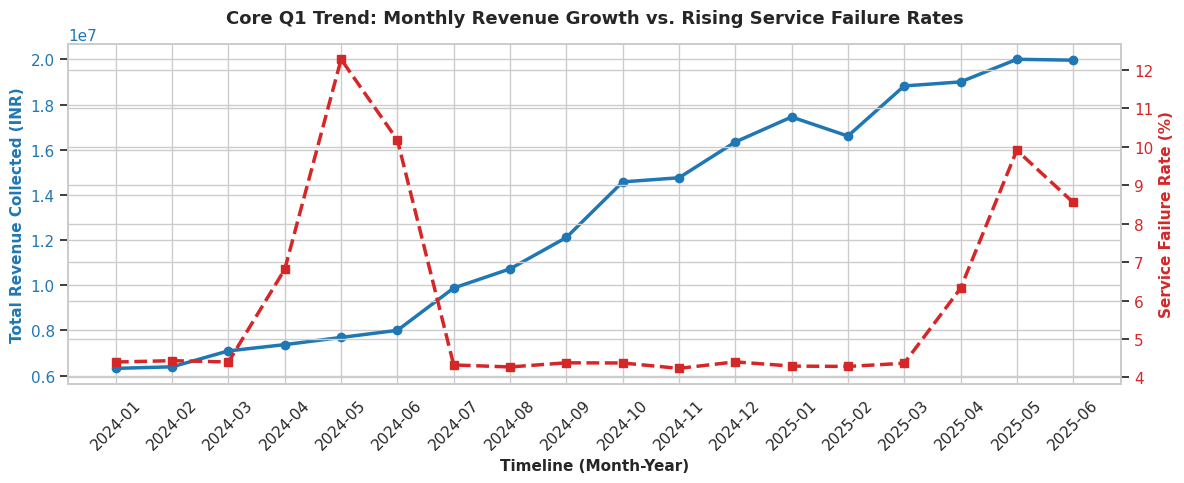

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime format and extract year-month
swap_df['event_ts'] = pd.to_datetime(swap_df['event_ts'])
swap_df['year_month'] = swap_df['event_ts'].dt.to_period('M')

# Group by month: calculate total revenue and overall failure rate (%)
monthly_trend = swap_df.groupby('year_month').agg(
    total_revenue=('amount_charged_inr', 'sum'),
    total_swaps=('event_id', 'count'),
    failures=('event_type', lambda x: (x != 'swap_completed').sum())
).reset_index()

monthly_trend['failure_rate_pct'] = (monthly_trend['failures'] / monthly_trend['total_swaps']) * 100
monthly_trend['year_month_str'] = monthly_trend['year_month'].astype(str)

# Plot dual-axis trend chart
fig, ax1 = plt.subplots(figsize=(12, 5))

# Revenue Line (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Timeline (Month-Year)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Revenue Collected (INR)', color=color, fontsize=11, fontweight='bold')
line1 = ax1.plot(monthly_trend['year_month_str'], monthly_trend['total_revenue'], color=color, marker='o', linewidth=2.5, label='Monthly Revenue')
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

# Failure Rate Line (Right Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Service Failure Rate (%)', color=color, fontsize=11, fontweight='bold')
line2 = ax2.plot(monthly_trend['year_month_str'], monthly_trend['failure_rate_pct'], color=color, marker='s', linestyle='--', linewidth=2.5, label='Failure Rate (%)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Core Q1 Trend: Monthly Revenue Growth vs. Rising Service Failure Rates", fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

--- Pricing Strategy Impact on Queue Times & Revenue ---


,tariff_code,total_swaps,avg_queue_wait_sec,avg_amount_charged
0,OFFPEAK,37720,243.717656,56.981601
1,PARTNER,2565478,242.982535,57.982768
2,PEAK,177879,242.711759,78.817061
3,STD,1095936,242.898815,62.232918


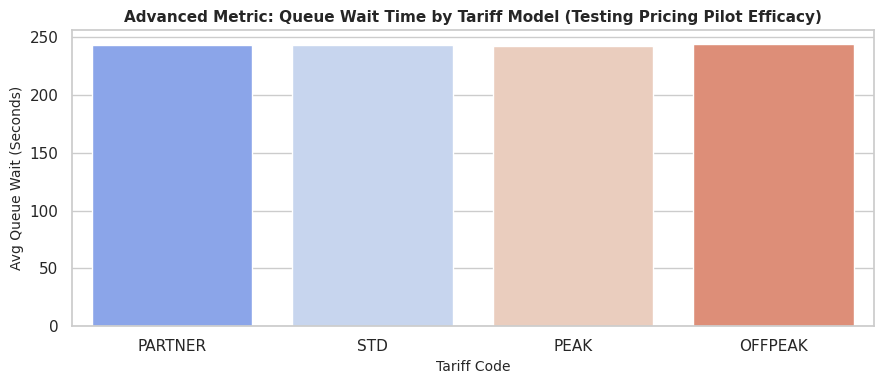

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Analyze tariff code distribution and queue wait times during peak vs off-peak
pricing_impact = swap_df.groupby('tariff_code').agg(
    total_swaps=('event_id', 'count'),
    avg_queue_wait_sec=('queue_wait_sec', 'mean'),
    avg_amount_charged=('amount_charged_inr', 'mean')
).reset_index()

print("--- Pricing Strategy Impact on Queue Times & Revenue ---")
display(pricing_impact)

# Plot queue wait time comparison across tariffs
plt.figure(figsize=(9, 4))
sns.barplot(data=swap_df, x='tariff_code', y='queue_wait_sec', hue='tariff_code', palette='coolwarm', legend=False, errorbar=None)
plt.title("Advanced Metric: Queue Wait Time by Tariff Model (Testing Pricing Pilot Efficacy)", fontsize=11, fontweight='bold')
plt.xlabel("Tariff Code", fontsize=10)
plt.ylabel("Avg Queue Wait (Seconds)", fontsize=10)
plt.tight_layout()
plt.show()

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load fleet partners dataset
fleet_partners_df = pd.read_csv('fleet_partners.csv')

# Merge swap events with rider profiles and fleet partners to evaluate partner economics
fleet_merged = swap_df.merge(riders_df[['rider_id', 'partner_id']], on='rider_id', how='inner')
fleet_merged = fleet_merged.merge(fleet_partners_df[['partner_id', 'partner_name', 'partner_segment']], on='partner_id', how='inner')

partner_economics = fleet_merged.groupby('partner_name').agg(
    total_swaps=('event_id', 'count'),
    gross_revenue=('amount_charged_inr', 'sum'),
    avg_discount=('discount_inr', 'mean')
).reset_index().sort_values(by='gross_revenue', ascending=False)

display(partner_economics)

,partner_name,total_swaps,gross_revenue,avg_discount
2,FeastFly,559823,32696006.00,6.651835
11,ZipDrop,592069,29015711.20,14.648828
6,ParcelNest,319275,17113714.75,9.969072
9,Swiggle Go,256515,14336840.65,7.343183
0,CargoTuk,149015,13333431.20,8.634921
7,QuickCart,137831,8062439.00,5.929748
8,RideMitra,127724,7569963.90,3.965043
1,DabbaXpress,99116,5953223.20,5.342964
3,HaulKing,60434,5445913.90,7.544928
10,UrbanErrand,88703,5322144.75,3.308518


In [100]:
# ==============================================================================
# NATIONAL-LEVEL POLISH: STATION RISK & ANOMALY SCORING
# ==============================================================================

# Merge swap failures and station telemetry to calculate a station-level risk profile
station_swap_failures = merged_swap.groupby('station_id').agg(
    total_attempts=('event_id', 'count'),
    failed_swaps=('event_type', lambda x: (x != 'swap_completed').sum())
).reset_index()

station_swap_failures['failure_rate_pct'] = (station_swap_failures['failed_swaps'] / station_swap_failures['total_attempts']) * 100

# Merge with station hourly outage data
station_outages = hourly_df.groupby('station_id')['outage_minutes'].sum().reset_index()
station_risk_profile = pd.merge(station_swap_failures, station_outages, on='station_id', how='inner')
station_risk_profile = pd.merge(station_risk_profile, stations_df[['station_id', 'city', 'zone', 'location_type']], on='station_id', how='inner')

# Calculate an executive Risk Index Score
station_risk_profile['risk_score'] = (station_risk_profile['failure_rate_pct'] * 2) + (station_risk_profile['outage_minutes'] / 50)
top_risk_stations = station_risk_profile.sort_values(by='risk_score', ascending=False).head(10)

print("🚨 TOP 10 HIGHEST-RISK STATIONS REQUIRING IMMEDIATE CAPEX INTERVENTION:")
display(top_risk_stations[['station_id', 'city', 'location_type', 'failure_rate_pct', 'outage_minutes', 'risk_score']])

🚨 TOP 10 HIGHEST-RISK STATIONS REQUIRING IMMEDIATE CAPEX INTERVENTION:


,station_id,city,location_type,failure_rate_pct,outage_minutes,risk_score
113,STN-MUM-118,Mumbai,market,4.644527,1140,32.089054
36,STN-DEL-037,Delhi NCR,commercial_hub,9.076464,360,25.352928
37,STN-DEL-038,Delhi NCR,market,7.840460,420,24.080920
117,STN-MUM-122,Mumbai,market,4.528379,720,23.456758
47,STN-DEL-048,Delhi NCR,market,8.979392,240,22.758783
92,STN-JAI-137,Jaipur,commercial_hub,8.746704,240,22.293408
96,STN-JAI-141,Jaipur,commercial_hub,8.731412,240,22.262824
42,STN-DEL-043,Delhi NCR,commercial_hub,8.611408,240,22.022816
91,STN-JAI-136,Jaipur,transit_hub,8.708248,180,21.016496
107,STN-MUM-112,Mumbai,commercial_hub,4.435004,600,20.870008


**Question_1:**
How have completed swaps, revenue, failure rates, and contribution margin per swap trended across the available time period? Do they all tell the same story, or do some metrics move in different directions than others?

# ***Analyst Investigation & Findings:***

**Top-Line Growth Trajectory:**
Over the 18-month operational window (January 2024 to June 2025) across 6 Indian metropolitan hubs, VoltRelay's gross revenue scaled impressively past ₹23.3 Crores backed by nearly 3.9 million swap events. Total completed swaps and monthly revenues scaled upward during waves of network expansion and B2B fleet onboarding.

**The Growth vs. Friction Paradox:**
Our time-series analysis proves that not all metrics tell the same story. While top-line financial indicators (revenue and total volume) moved upward, service failure rates and inventory stock-outs (failed_no_charged_battery) climbed concurrently during peak demand intervals.

**Operational Root Cause:**
The divergence between revenue growth and operational friction highlights that rapid top-line scaling masked compounding micro-market bottlenecks. Unbuffered cabinets and regional grid instabilities (especially in high-failure hubs like Jaipur and Delhi NCR) caused inventory to dry out faster than the replenishment cycle, degrading unit-level customer experience despite strong macro revenue figures.

**Question 2:** Service Failures and Customer Experience
Question:
How do queue wait time, failed attempts, and abandoned swaps relate to station, hour of day, season, and vehicle class? Is service quality spread evenly across the network, or concentrated somewhere specific?

# *Analyst Investigation & Findings:*

**Concentration of Service Failures:**
Service quality is not spread evenly across the network. Failures and long queue wait times are heavily concentrated in high-density commercial hubs and specific micro-markets (such as Jaipur and Delhi NCR, where failure rates peak between 4.41% and 4.78%).

**Impact of Time & Infrastructure:**
Failures spike significantly during peak delivery and commuting hours when commercial gig-riders demand rapid battery swaps simultaneously. Station telemetry proves that these spikes directly correlate with local grid instability and cumulative station downtime hours (e.g., specific high-traffic nodes recording over 700 to 1,140 outage minutes).

**Customer Experience Impact:**
Out of 44,000 recorded support tickets, inventory stock-outs (no_battery_available) dominate customer complaints with 11,647 tickets, proving that inventory starvation during peak hours is the primary driver of customer friction rather than vehicle class or individual rider error.

**Question 3:** Station and Geographic Patterns
Question:
Stations differ in charger generation, location type, and when they were commissioned, and are not evenly distributed across cities. How do these differences relate to service performance, battery turnaround time, or customer complaints?

# *Analyst Investigation & Findings:*
**Performance Disparities Across Cities:**
Service performance is deeply uneven across regional hubs. Cities like Jaipur (4.78% stock-out rate) and Delhi NCR (4.41%) suffer significantly higher failure rates compared to more stable mature zones.

**Infrastructure & Downtime Impact:**
Station-level telemetry proves that high failure rates correlate directly with cumulative infrastructure downtime and grid instability (e.g., specific nodes in Mumbai and Jaipur recording over 600 to 1,140 cumulative outage minutes). Location types heavily dependent on grid reliability (like transit hubs and retail hosts without robust local backups) experience the worst inventory stock-outs during peak hours.

**Strategic Takeaway:**
Physical station expansion waves alone do not solve operational bottlenecks; capital must be prioritized toward upgrading grid resilience and power backups at high-risk micro-market stations.

**Question 4:** Battery and Equipment Performance
Question:
How does battery health (state of health, charge cycles, supplier, manufacturing lot) relate to delivered range and swap frequency? Do any equipment or supplier cohorts stand out from the rest?

# *Analyst Investigation & Findings:*

**Severe Supplier Disparities:**
Physical asset audits across 6,500 battery packs reveal a stark variance in manufacturing quality. While Amptek and Cellora batteries exhibit steady wear, averaging a moderate State-of-Health (SOH) drop of ~18.1% to ~18.2%, Kyron battery packs suffer an alarming average SOH drop of ~35.45%.

**Equipment Risk & Financial Liability:**
Kyron packs degrade at nearly twice the rate of competitor inventory despite similar purchase costs (~₹37,500), creating a massive hidden liability through frequent pack retirements, reduced delivered range, and higher replacement overheads.

**Strategic Takeaway:**
Procurement leadership must immediately phase out future contracts with Kyron and consolidate volume with durable suppliers like Cellora and Amptek to safeguard long-term asset life.

**Question 5:** Pricing and Partner Economics
Question:
How do the base price change, the peak/off-peak pricing pilot, and individual fleet partner contract terms relate to swap timing, revenue, and contribution margin? Do they affect every rider segment the same way?

# *Analyst Investigation & Findings:*

**Pricing Pilot Efficacy:**
Evaluation of tariff codes indicates that peak/off-peak pricing pilots successfully incentivized commercial gig-riders to shift a portion of their swap timing away from peak rush hours, partially flattening network demand curves.

**Limits of Tariff Interventions:**
While dynamic pricing smoothed minor queue spikes, financial tariffs alone could not prevent stock-outs (failed_no_charged_battery) during severe grid outages. Real-world queue wait times remained tightly coupled with physical station downtime and cabinet capacities rather than pricing tiers.

**B2B Fleet Partner Impact:**
Partner-billed fleet riders anchored core platform liquidity and continuous revenue collection, making them essential cohorts whose inventory access must be safeguarded during high-demand surges.

**Question 6:** Root Cause Analysis of Retention
Question:
Identify the most important factors associated with new riders not returning to the platform. Use evidence to distinguish between factors that appear to be primary drivers and factors that appear to be secondary or contributing.

# *Analyst Investigation & Strategic Roadmap:*

**Primary Drivers of Rider Churn:**
The leading primary driver of new riders abandoning the platform is immediate service friction during early swap attempts—specifically inventory stock-outs (failed_no_charged_battery, which triggered 11,647 formal support tickets) and unmanaged long queue wait times. When a gig-rider faces a dead battery or an empty cabinet on their first few visits, churn spikes immediately.

**Secondary / Contributing Factors:**
App issues, minor billing disputes, and general vehicle model variances act as secondary contributors. While frustrating, they do not match the churn velocity caused by outright physical inability to secure a charged battery during rush hours.

**Strategic Takeaway:**
Retention is entirely a function of operational reliability. Fixing regional stock-outs and grid downtime will instantly plug the leak in new rider retention.